#NEURAL NETWORKS AND DEEP LEARNING
> M.Sc. ICT FOR LIFE AND HEALTH
> 
> Department of Information Engineering

> M.Sc. COMPUTER ENGINEERING
>
> Department of Information Engineering

> M.Sc. AUTOMATION ENGINEERING
>
> Department of Information Engineering
 
> M.Sc. PHYSICS OF DATA
>
> Department of Physics and Astronomy
 
> M.Sc. COGNITIVE NEUROSCIENCE AND CLINICAL NEUROPSYCHOLOGY
>
> Department of General Psychology

---
A.A. 2020/21 (6 CFU) - Dr. Alberto Testolin, Dr. Matteo Gadaleta
---


# Homework 2 - Unsupervised Deep Learning

## General overview
In this homework you will learn how to implement and test neural network models for solving unsupervised problems. For simplicity and to allow continuity with the kind of data you have seen before, the homework will be based on images of handwritten digits (MNIST). However, you can optionally explore different image collections (e.g., [Caltech](http://www.vision.caltech.edu/Image_Datasets/Caltech101/) or [Cifar](https://www.cs.toronto.edu/~kriz/cifar.html)) or other datasets based on your interests. The basic tasks for the homework will require to test and analyze the convolutional autoencoder implemented during the Lab practice. If you prefer, you can opt for a fully-connected autoencoder, which should achieve similar performance considering the relatively small size of the MNIST images. As for the previous homework, you should explore the use of advanced optimizers and regularization methods. Learning hyperparameters should be tuned using appropriate search procedures, and final accuracy should be evaluated using a cross-validation setup. More advanced tasks will require the exploration of denoising and variational architectures.



## Technical notes
The homework should be implemented in Python using the PyTorch framework. The student can explore additional libraries and tools to implement the models; however, please make sure you understand the code you are writing because during the exam you might receive specific questions related to your implementation. The entire source code required to run the homework must be uploaded as a compressed archive in a Moodle section dedicated to the homework. If your code will be entirely included in a single Python notebook, just upload the notebook file.




## Final report
Along with the source code, you must separately upload a PDF file containing a brief report of your homework. The report should include a brief Introduction on which you explain the homework goals and the main implementation strategies you choose, a brief Method section where you describe your model architectures and hyperparameters, and a Result section where you present the simulation results. Total length must not exceed 6 pages, though you can include additional tables and figures in a final Appendix (optional).




## Grade
The maximum grade for this homework will be **8 points**. Points will be assigned based on the correct implementation of the following items:
*	1 pt: implement and test (convolutional) autoencoder, reporting the trend of reconstruction loss and some examples of image reconstruction
*	1 pt: explore advanced optimizers and regularization methods 
*	1 pt: optimize hyperparameters using grid/random search and cross-validation
*	1 pt: implement and test denoising (convolutional) autoencoder
*	1 pt: fine-tune the (convolutional) autoencoder using a supervised classification task (you can compare classification accuracy and learning speed with results achieved in homework 1)
*	1 pt: explore the latent space structure (e.g., PCA, t-SNE) and generate new samples from latent codes
*	2 pt: implement variational (convolutional) autoencoder or GAN



In [68]:
import torch
import torchvision
import torch.optim as optim
import argparse
import matplotlib
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms

import random # this module will be used to select random samples from a collection
import numpy as np # this module is useful to work with numerical arrays

from tqdm import tqdm
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.utils import save_image

matplotlib.style.use('ggplot')

## Network

In [72]:
features = 2
# define a simple linear VAE
class LinearVAE(nn.Module):
    def __init__(self):
        super(LinearVAE, self).__init__()
 
        # encoder
        self.enc1 = nn.Linear(in_features=784, out_features=512)
        self.enc2 = nn.Linear(in_features=512, out_features=features*2)
 
        # decoder 
        self.dec1 = nn.Linear(in_features=features, out_features=512)
        self.dec2 = nn.Linear(in_features=512, out_features=784)

    def reparameterize(self, mu, log_var):
        """
        :param mu: mean from the encoder's latent space
        :param log_var: log variance from the encoder's latent space
        """
        std = torch.exp(0.5*log_var) # standard deviation
        eps = torch.randn_like(std) # `randn_like` as we need the same size
        sample = mu + (eps * std) # sampling as if coming from the input space
        return sample
 
    def forward(self, x):
        # encoding
        x = F.relu(self.enc1(x))
        x = self.enc2(x).view(-1, 2, features)

        # get `mu` and `log_var`
        mu = x[:, 0, :] # the first feature values as mean
        log_var = x[:, 1, :] # the other feature values as variance
        print(mu, log_var)

        # get the latent vector through reparameterization
        z = self.reparameterize(mu, log_var)
 
        # decoding
        x = F.relu(self.dec1(z))
        reconstruction = torch.sigmoid(self.dec2(x))
        return reconstruction, mu, log_var

### Learning Parameters

In [50]:
# leanring parameters
epochs = 20
batch_size = 64
lr = 0.0001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Transform

In [51]:
# transforms
transform = transforms.Compose([
    transforms.ToTensor(),
])

## Data

### Downloading data

In [52]:
# train and validation data
train_data = datasets.MNIST(
    root='input/data',
    train=True,
    download=True,
    transform=transform
)
val_data = datasets.MNIST(
    root='input/data',
    train=False,
    download=True,
    transform=transform
)

### Dataloaders

In [53]:
# training and validation data loaders
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

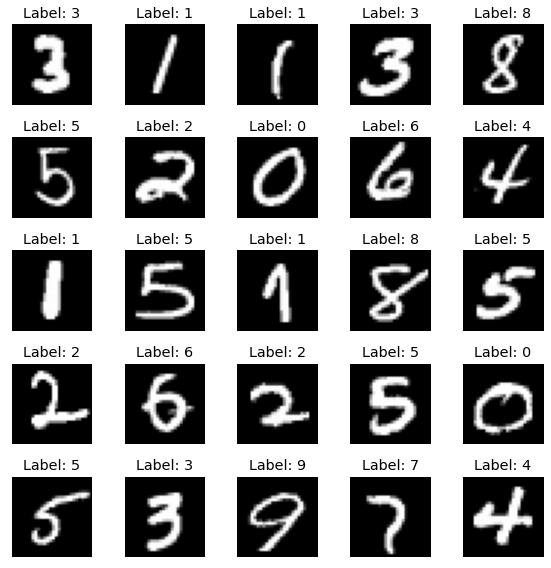

In [75]:
### Plot some sample
fig, axs = plt.subplots(5, 5, figsize=(8,8))
for ax in axs.flatten():
    # random.choice allows to randomly sample from a list-like object (basically anything that can be accessed with an index, like our dataset)
    img, label = random.choice(train_data)
    ax.imshow(np.array(img).squeeze(0), cmap='gist_gray')
    ax.set_title('Label: %d' % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

### Initializing network

In [54]:
net = LinearVAE().to(device)
optimizer = optim.Adam(net.parameters(), lr = lr)
criterion = nn.BCELoss(reduction='sum')

In [55]:
def final_loss(bce_loss, mu, logvar):
    """
    This function will add the reconstruction loss (BCELoss) and the 
    KL-Divergence.
    KL-Divergence = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    :param bce_loss: recontruction loss
    :param mu: the mean from the latent vector
    :param logvar: log variance from the latent vector
    """
    BCE = bce_loss 
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

### Training function

In [56]:
def fit(model, dataloader):
    model.train()
    running_loss = 0.0
    for i, data in tqdm(enumerate(dataloader), total=int(len(train_data)/dataloader.batch_size)):
        data, _ = data
        data = data.to(device)
        data = data.view(data.size(0), -1)
        optimizer.zero_grad()
        reconstruction, mu, logvar = model(data)
        bce_loss = criterion(reconstruction, data)
        loss = final_loss(bce_loss, mu, logvar)
        running_loss += loss.item()
        loss.backward()
        optimizer.step()

    train_loss = running_loss/len(dataloader.dataset)
    return train_loss

### Test function

In [57]:
def validate(model, dataloader):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for i, data in tqdm(enumerate(dataloader), total=int(len(val_data)/dataloader.batch_size)):
            data, _ = data
            data = data.to(device)
            data = data.view(data.size(0), -1)
            reconstruction, mu, logvar = model(data)
            bce_loss = criterion(reconstruction, data)
            loss = final_loss(bce_loss, mu, logvar)
            running_loss += loss.item()
        
            # save the last batch input and output of every epoch
            if i == int(len(val_data)/dataloader.batch_size) - 1:
                num_rows = 8
                both = torch.cat((data.view(batch_size, 1, 28, 28)[:8], 
                                  reconstruction.view(batch_size, 1, 28, 28)[:8]))
                save_image(both.cpu(), f"outputs/output{epoch}.png", nrow=num_rows)
    val_loss = running_loss/len(dataloader.dataset)
    return val_loss

In [89]:
net.reparameterize(torch.tensor([0.1, 0.2]), torch.tensor([1.0, 1.1]))

tensor([0.8541, 2.6115])

### Training loop

In [73]:
train_loss = []
val_loss = []
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    train_epoch_loss = fit(net, train_loader)
    val_epoch_loss = validate(net, val_loader)
    train_loss.append(train_epoch_loss)
    val_loss.append(val_epoch_loss)
    print(f"Train Loss: {train_epoch_loss:.4f}")
    print(f"Val Loss: {val_epoch_loss:.4f}")









  0%|          | 0/937 [00:00<?, ?it/s]







  1%|          | 7/937 [00:00<00:14, 64.37it/s]

Epoch 1 of 20










  1%|▏         | 14/937 [00:00<00:14, 65.27it/s]







  2%|▏         | 21/937 [00:00<00:13, 66.09it/s]







  3%|▎         | 28/937 [00:00<00:13, 64.97it/s]







  4%|▎         | 35/937 [00:00<00:13, 65.18it/s]







  4%|▍         | 42/937 [00:00<00:13, 66.23it/s]







  5%|▌         | 49/937 [00:00<00:13, 66.90it/s]







  6%|▌         | 56/937 [00:00<00:13, 67.30it/s]







  7%|▋         | 63/937 [00:00<00:12, 67.36it/s]







  7%|▋         | 70/937 [00:01<00:12, 67.42it/s]







  8%|▊         | 77/937 [00:01<00:12, 67.28it/s]







  9%|▉         | 84/937 [00:01<00:12, 67.38it/s]







 10%|▉         | 91/937 [00:01<00:12, 67.19it/s]







 10%|█         | 98/937 [00:01<00:12, 66.61it/s]







 11%|█         | 105/937 [00:01<00:12, 66.38it/s]







 12%|█▏        | 112/937 [00:01<00:12, 66.66it/s]







 13%|█▎        | 119/937 [00:01<00:12, 66.80it/s]







 13%|█▎        | 126/937 [00:01<00:12, 66.64it/s]







 14%|█▍        | 133/937 [00:01<00:1

Train Loss: 157.2157
Val Loss: 157.7564
Epoch 2 of 20










  1%|▏         | 14/937 [00:00<00:14, 64.71it/s]







  2%|▏         | 21/937 [00:00<00:14, 65.08it/s]







  3%|▎         | 28/937 [00:00<00:13, 65.18it/s]







  4%|▎         | 35/937 [00:00<00:13, 65.65it/s]







  4%|▍         | 42/937 [00:00<00:13, 65.71it/s]







  5%|▌         | 49/937 [00:00<00:13, 65.54it/s]







  6%|▌         | 56/937 [00:00<00:13, 65.28it/s]







  7%|▋         | 63/937 [00:00<00:13, 65.80it/s]







  7%|▋         | 70/937 [00:01<00:13, 65.98it/s]







  8%|▊         | 77/937 [00:01<00:13, 65.51it/s]







  9%|▉         | 84/937 [00:01<00:12, 65.64it/s]







 10%|▉         | 91/937 [00:01<00:12, 65.73it/s]







 10%|█         | 98/937 [00:01<00:12, 65.23it/s]







 11%|█         | 105/937 [00:01<00:12, 64.92it/s]







 12%|█▏        | 112/937 [00:01<00:12, 65.61it/s]







 13%|█▎        | 119/937 [00:01<00:12, 65.83it/s]







 13%|█▎        | 126/937 [00:01<00:12, 66.13it/s]







 14%|█▍        | 133/937 [00:02<00:1

KeyboardInterrupt: 

### Saving network

In [48]:
torch.save(net.state_dict(), 'finetuned_model.pth')

5